In [1]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 
from tqdm import tqdm

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.LeafletFAminibatch as LeafletFAminibatch
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

# Simulation source code
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
importlib.reload(sim)


Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

In [2]:
# Define base output directory
import json 
base_output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19"

# Get parameter set ID from command line
# param_id = int(sys.argv[1])
param_id = 0 

# Load parameters
param_file = os.path.join(base_output_dir, "parameter_combinations.json")
with open(param_file, "r") as f:
    param_list = json.load(f)
params = param_list[param_id] 

# Define output directory
output_dir = os.path.join(base_output_dir, f"run_{param_id}")
os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19/run_0


In [3]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

In [4]:
# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")

### Simulate data!

In [5]:
# Filter adata to only include junctions that have non_zero_count_cells >= 10
adata = adata[:, adata.var["non_zero_count_cells"] > 2]

# choose which column should be used for maintaining cell labels when simulating data...
sim_label_column = params["sim_label_column"] #"cell_type_grouped" # or set to None then cells will be randomly assigned to groups
proportion_negative = params["proportion_negative"]

if params["sim_label_column"] is None:
    K = 2
else:
    K = len(adata.obs[sim_label_column].unique())

# Set up some useful params 
params["input_conc"] = None if params["input_conc"] is None else torch.tensor(np.inf)
input_conc = params["input_conc"]
junc_specific_prior = params["junc_specific_prior"] # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
waypoints_use = params["waypoints_use"] # don't have waypoints in simulated data

In [6]:
sim_label_column = "cell_type_grouped"
K = len(adata.obs[sim_label_column].unique())
proportion_negative = 0.5
print(K)

sim_label_column = None
K = 2 
proportion_negative = 0.5
print(K)

9
2


In [7]:
# Preprocess the data
adata_filtered = sim.preprocess_adata(adata, sim_label_column, "cell_by_cluster_matrix")
# Simulate data
_, _, adata_input, cell_type_psi_df = sim.simulate_and_prepare_data(adata_filtered, K, float_type, proportion_negative, sim_label_column)

# Write cell_type_psi_df to a CSV file 
cell_type_psi_df_path = os.path.join(output_dir, 'cell_type_psi_df.csv')
cell_type_psi_df.to_csv(cell_type_psi_df_path, index=False)

No cell type column specified. Skipping filtering of ATSEs.


/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:281: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_junc_counts =  adata_input.var.groupby(["event_id"]).agg({"junction_id": "count"}).reset_index()
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:307: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, juncs_c in tqdm( adata_input.var.groupby("event_id")):


Cluster_Counts nnz: 14508282
Junction_Counts nnz: 8005924
The number of unique junctions included in the simulation data is: 10173
The number of unique clusters included in the simulation data is: 3391


100%|██████████| 3391/3391 [00:02<00:00, 1143.09it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Cluster_Counts nnz: 14005551
Junction_Counts nnz: 7579214
The proportion of negative ASEs to set is: 0.5
The number of cell types is: 2
The number of cells is: 19942
The number of junctions is: 9801
Number of negative labels (0): 1633
Number of positive labels (1): 1634


...

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'junc_ratio' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Cluster_Counts nnz: 13838022
Junction_Counts nnz: 11966819


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Data successfully simulated and prepared!


/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [8]:
# Check column names that are not strings
problematic_columns = [col for col in adata_input.var.columns if not isinstance(col, str)]
print("Problematic columns:", problematic_columns)

# Convert problematic column names to strings
adata_input.var.columns = adata_input.var.columns.map(str)

if adata_input.var.columns.duplicated().any():
    print("Duplicate column names found. Resolving by renaming.")
    adata_input.var.columns = pd.io.parsers.ParserBase({'names': adata_input.var.columns})._maybe_dedup_names(adata_input.var.columns)

import scipy 
from scipy.sparse import csr_matrix

# Check if any layers are in COO format
for layer_name, layer_data in adata_input.layers.items():
    if isinstance(layer_data, scipy.sparse.coo_matrix):
        print(f"Converting {layer_name} from COO to CSR format.")
        adata_input.layers[layer_name] = layer_data.tocsr()

# Convert adata.X if it is in COO format
if isinstance(adata_input.X, scipy.sparse.coo_matrix):
    print("Converting adata.X from COO to CSR format.")
    adata_input.X = adata_input.X.tocsr()

# Convert varm, obsm, and obsp if they contain COO matrices
for attr in ['varm', 'obsm', 'obsp']:
    for key in getattr(adata_input, attr).keys():
        if isinstance(getattr(adata_input, attr)[key], scipy.sparse.coo_matrix):
            print(f"Converting {attr}['{key}'] from COO to CSR format.")
            getattr(adata_input, attr)[key] = getattr(adata_input, attr)[key].tocsr()


Problematic columns: [0, 1]
Converting cell_by_junction_matrix from COO to CSR format.
Converting cell_by_cluster_matrix from COO to CSR format.


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


In [9]:
# save adata_input to h5ad file
output_anndata = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/SIMULATED"
# get todays date
#today = datetime.datetime.now()
#today = today.strftime("%Y-%m-%d")
#adata_input.write_h5ad(f"{output_anndata}/simulated_data_{today}.h5ad")
#print(f"Simulated anndata saved to {output_anndata}/simulated_data_{today}.h5ad")

### Initialize and train the model using the simulated counts!

In [10]:
num_inits = params["num_inits"]
num_epochs = params["num_epochs"]
num_samples = params["num_samples"]
lr = params["lr"]
ELBO_num_particles = params["ELBO_num_particles"]
print_epochs = 1

In [11]:
ELBO_num_particles

10

In [12]:
lr = 0.5
num_inits = 3

In [13]:
# Let's initialize the LeafletFA class 
importlib.reload(LeafletFA)
log_wandb = False 
leaflet_model = LeafletFA.LeafletFA(adata=adata_input, K=K, 
                                    junc_specific_prior = True, 
                                    waypoints_use=waypoints_use, 
                           input_conc_prior = None, 
                           num_epochs=500,
                           patience=5, 
                           min_delta=10, 
                           print_epochs=10, 
                           ELBO_num_particles=5, 
                           lr=lr, gamma=0.05, 
                           num_samples=500)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()

Torch Version: 2.4.1.post300
CUDA Version: 12.0
Taking in the AnnData object with 19942 cells and 9801 junctions.
Processing AnnData on cuda


Random seeds: [5228, 2655, 7294]
Training LeafletFA with 3 initializations.
Input concentration prior: None
Junction-specific prior: True
Initial K to learn: 2
Random initialization of variational parameters!
-------------------------------------------------
Initialization #1 with seed 5228
-------------------------------------------------
Training in progress for 500 epochs!
Epoch 0: Loss = 80311094.35962313
The current learning rate is 0.4970132242418252
Epoch 10: Loss = 54266079.01805772
The current learning rate is 0.4681093808638603
Epoch 20: Loss = 48462286.9336525
The current learning rate is 0.4408864427843254
Epoch 30: Loss = 43667878.088138096
The current learning rate is 0.41524665682260237
Epoch 40: Loss = 40835561.244828805
The current learning rate is 0.3910979546420255
Epoch 50: Loss = 39527089.491415426
The current learning rate is 0.36835362214733236
Epoch 60: Loss = 38784934.41967326
The current learning rate is 0.3469319881083308
Epoch 70: Loss = 37983451.7464489
The

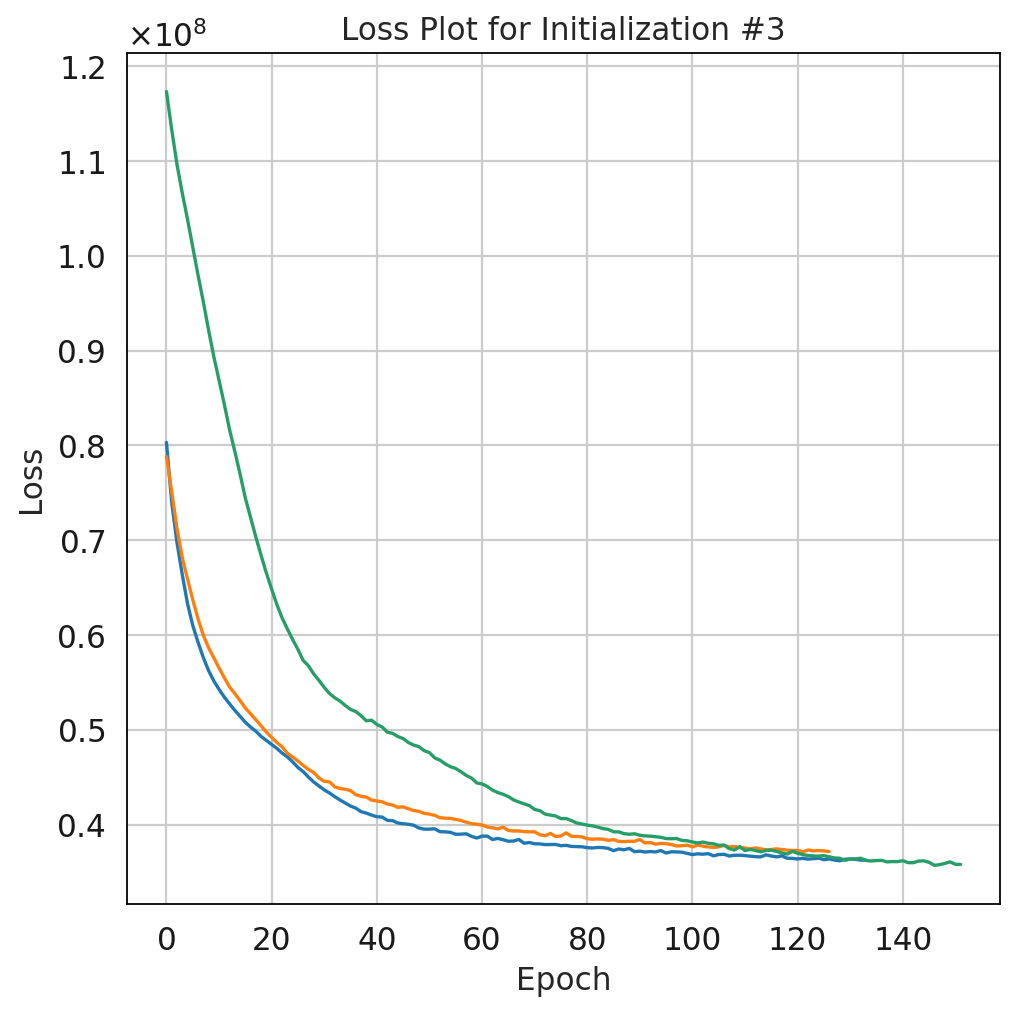

In [14]:
# Train the model 
leaflet_model.train(num_initializations=num_inits)

# Get the best initialization and extract all the latent variables at this initialization
# If you want the latent variables from a different initialization, you can pass the index of that initialization to the get_all_variables() function
leaflet_model.get_all_variables()

In [15]:
leaflet_model.pi, leaflet_model.alpha_pi

(array([0.49808633, 0.5019136 ], dtype=float32),
 array(1.3610375, dtype=float32))

Initialization 1 vs Initialization 2: Matched pairs [(0, 1), (1, 0)]
Initialization 1 vs Initialization 3: Matched pairs [(0, 1), (1, 0)]
Initialization 2 vs Initialization 3: Matched pairs [(0, 0), (1, 1)]
Assignment Correlation Report:
Average Pairwise Correlation: 0.9984
Median Pairwise Correlation: 0.9984
Minimum Pairwise Correlation: 0.9983



/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


<Figure size 560x560 with 0 Axes>

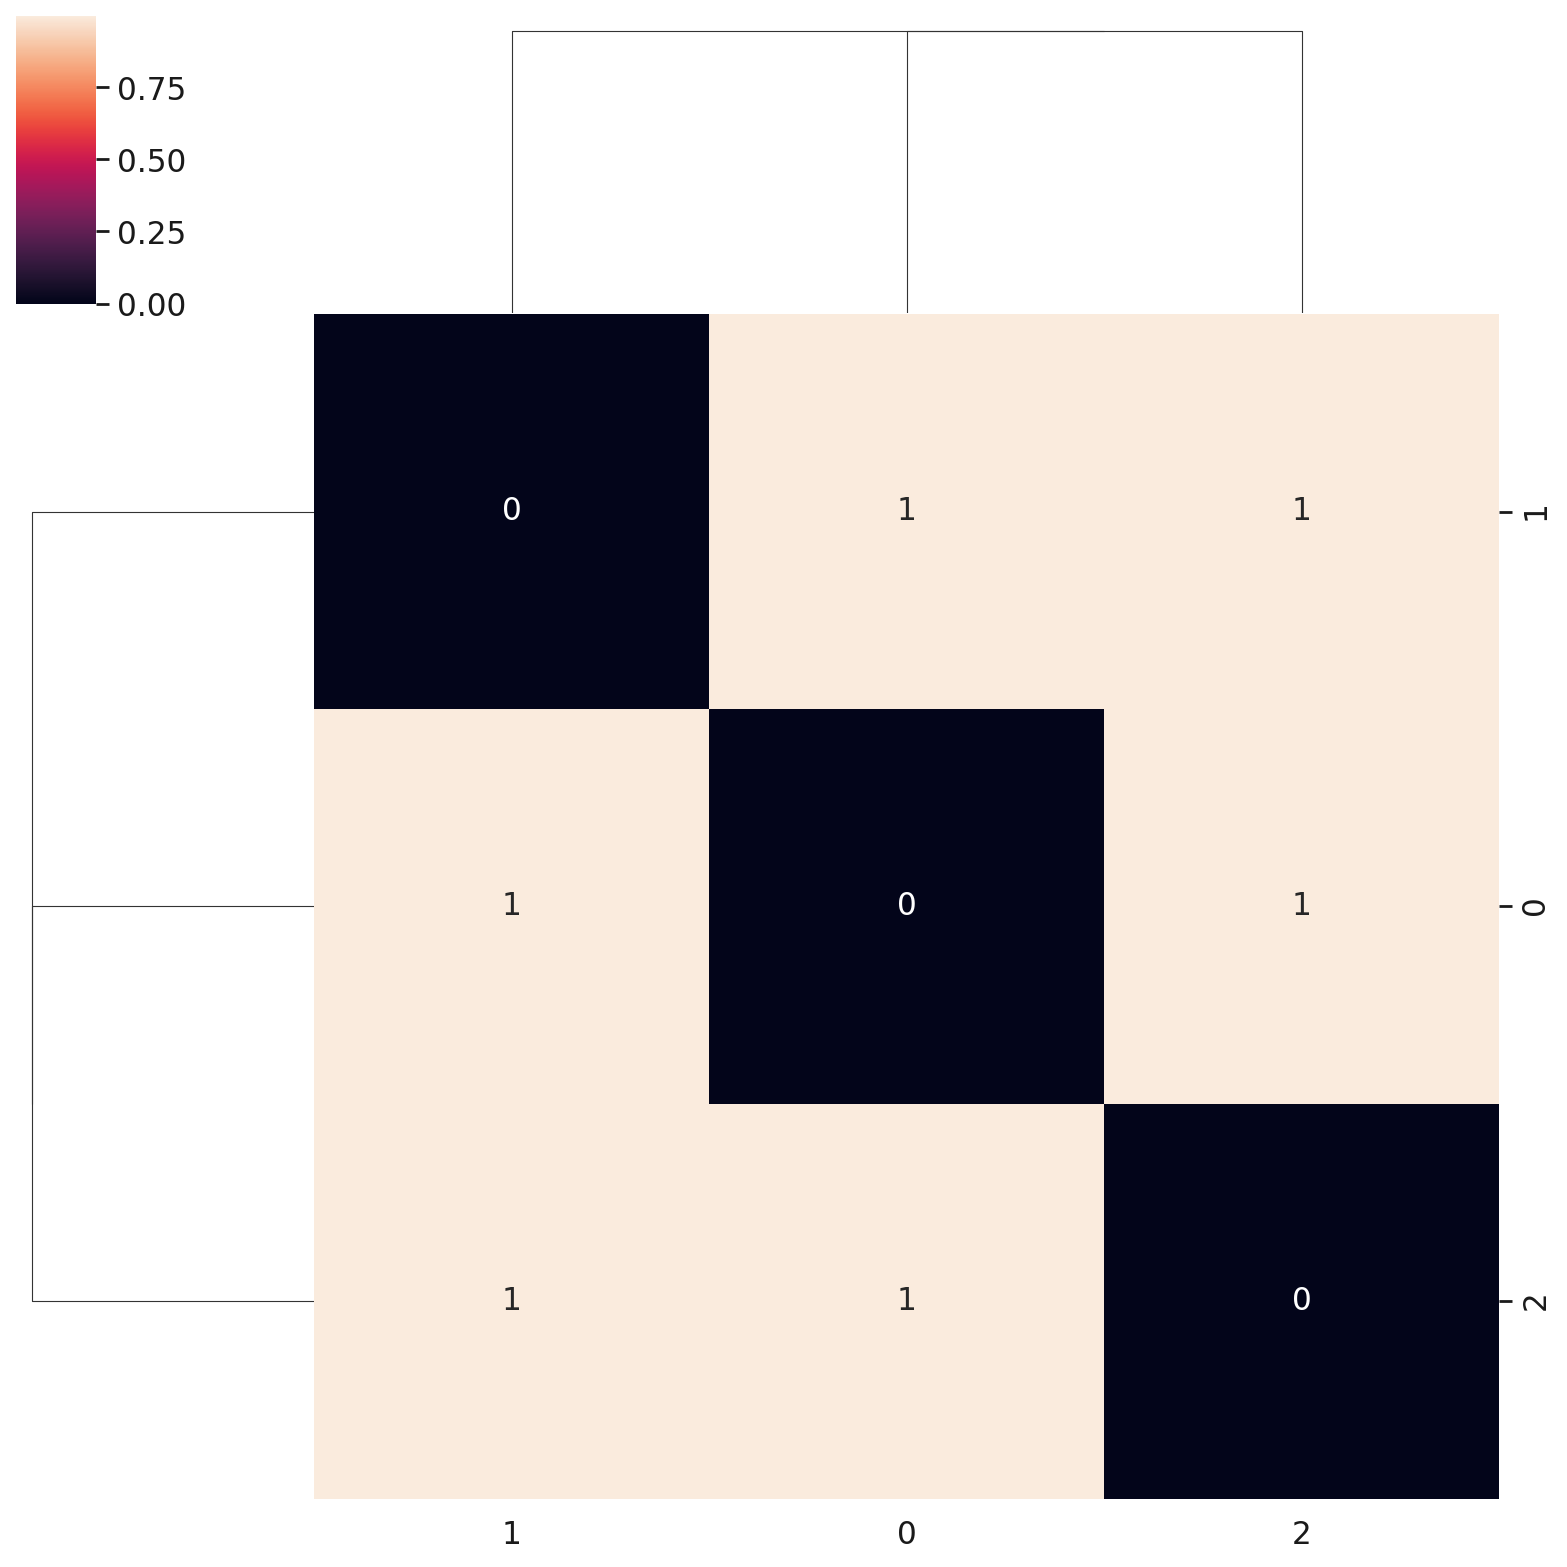

In [16]:
# let's look at the results 
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in leaflet_model.latent_results]

# Calculate correlations between initializations if more than 2 
if num_inits > 1:
    avg_corr, median_corr, min_corr = utils.calculate_and_plot_correlations(assign_matrices)
else: 
    avg_corr, median_corr, min_corr = None, None, None  # Set default values when there's only one initialization

In [17]:
# Prune K: note this updates all the latent variables in the model to only include estimates for the pruned K
leaflet_model.prune_K()

The K before pruning is 2
The K after pruning is 2
Upating K to 2 in the LeafletFA object.


In [18]:
LEAFLETFA_LATENT_KEY = "X_leafletFA"
adata_input.obsm[LEAFLETFA_LATENT_KEY] = leaflet_model.assign_post # assign_post is the posterior assignment cell-factor activity matrix 
sc.pp.neighbors(adata_input, use_rep=LEAFLETFA_LATENT_KEY, n_neighbors=10)

In [19]:
sc.tl.umap(adata_input)
sc.pl.umap(adata_input, color=["cell_type"])

KeyboardInterrupt: 

In [20]:
cell_tye_silhouette = ds.calculate_silhouette_score(leaflet_model.assign_post, adata_input.obs.cell_type.values)
print(f"Silhouette score for cell types: {cell_tye_silhouette}")

Silhouette score for cell types: 0.9387698769569397


In [21]:
# extract imputed values 
assign_matrix = leaflet_model.assign_post
psi_matrix = leaflet_model.psi_learned

assign_matrix.shape, psi_matrix.shape

imputed_values = assign_matrix @ psi_matrix
imputed_values.shape # cells by juncs 

# add imputed values to adata_input as a layer called "imputed_PSI"
adata_input.layers["imputed_PSI"] = imputed_values

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


In [22]:
adata_input.layers

Layers with keys: cell_by_junction_matrix, cell_by_cluster_matrix, junc_ratio, Cluster_Counts, Junction_Counts, imputed_PSI

In [23]:
# Check column names that are not strings
problematic_columns = [col for col in adata_input.var.columns if not isinstance(col, str)]
print("Problematic columns:", problematic_columns)

# Convert problematic column names to strings
adata_input.var.columns = adata_input.var.columns.map(str)

if adata_input.var.columns.duplicated().any():
    print("Duplicate column names found. Resolving by renaming.")
    adata_input.var.columns = pd.io.parsers.ParserBase({'names': adata_input.var.columns})._maybe_dedup_names(adata_input.var.columns)

import scipy 
from scipy.sparse import csr_matrix

# Check if any layers are in COO format
for layer_name, layer_data in adata_input.layers.items():
    if isinstance(layer_data, scipy.sparse.coo_matrix):
        print(f"Converting {layer_name} from COO to CSR format.")
        adata_input.layers[layer_name] = layer_data.tocsr()

# Convert adata.X if it is in COO format
if isinstance(adata_input.X, scipy.sparse.coo_matrix):
    print("Converting adata.X from COO to CSR format.")
    adata_input.X = adata_input.X.tocsr()

# Convert varm, obsm, and obsp if they contain COO matrices
for attr in ['varm', 'obsm', 'obsp']:
    for key in getattr(adata_input, attr).keys():
        if isinstance(getattr(adata_input, attr)[key], scipy.sparse.coo_matrix):
            print(f"Converting {attr}['{key}'] from COO to CSR format.")
            getattr(adata_input, attr)[key] = getattr(adata_input, attr)[key].tocsr()

# save adata_input to h5ad file
output_anndata = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/SIMULATED"
# get todays date
today = datetime.datetime.now()
today = today.strftime("%Y-%m-%d")
adata_input.write_h5ad(f"{output_anndata}/simulated_data_{today}.h5ad")
print(f"Simulated anndata saved to {output_anndata}/simulated_data_{today}.h5ad")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
... storing 'event_id' as categorical
... storing 'chr' as categorical
... storing 'start' as categorical
... storing 'end' as categorical
... storing 'sample_label' as categorical
... storing 'true_label' as categorical


Problematic columns: []
Converting Cluster_Counts from COO to CSR format.
Converting Junction_Counts from COO to CSR format.
Simulated anndata saved to /gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/SIMULATED/simulated_data_2025-03-24.h5ad


In [24]:
# count "sample_label" and "true_label" columns in the adata_input.obs dataframe co-occurence
# what's the min value for difference for positive and negative true_labels 
adata_input.var[adata_input.var["true_label"] == "negative"].difference.max()
adata_input.var[adata_input.var["true_label"] == "positive"].difference.min(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.median(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.max()

(0.000818491, 0.3141136, 0.987349)

In [25]:
# let's relabel "true_label" column values to "negative" if difference is less than 0.1 and "positive" otherwise
adata_input.var["true_label"] = np.where(adata_input.var["difference"] < 0.1, "negative", "positive")
adata_input.var[adata_input.var["true_label"] == "positive"].difference.min(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.median(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.max()

(0.10035929, 0.33727032, 0.987349)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


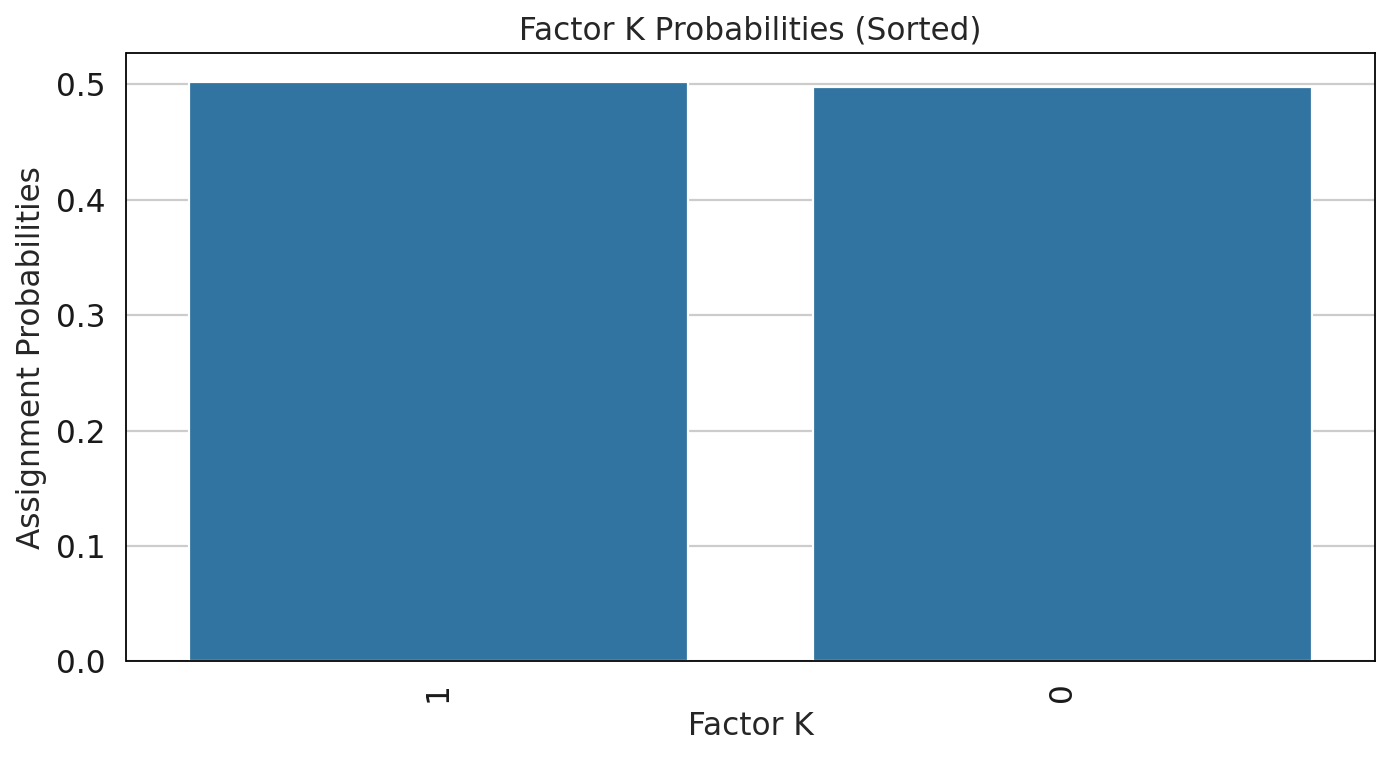

In [26]:
pi_df = pd.DataFrame(leaflet_model.pi, columns=["factor_assignment_probabilities"])
pi_df["factor_K"] = pi_df.index

# Sort by factor_assignment_probabilities in descending order
pi_df = pi_df.sort_values(by="factor_assignment_probabilities", ascending=False)

# Make sorted barplot
plt.figure(figsize=(10, 5))
sns.barplot(x="factor_K", y="factor_assignment_probabilities", data=pi_df, order=pi_df["factor_K"])
plt.title("Factor K Probabilities (Sorted)")
plt.xlabel("Factor K")
plt.ylabel("Assignment Probabilities")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors
plt.show()

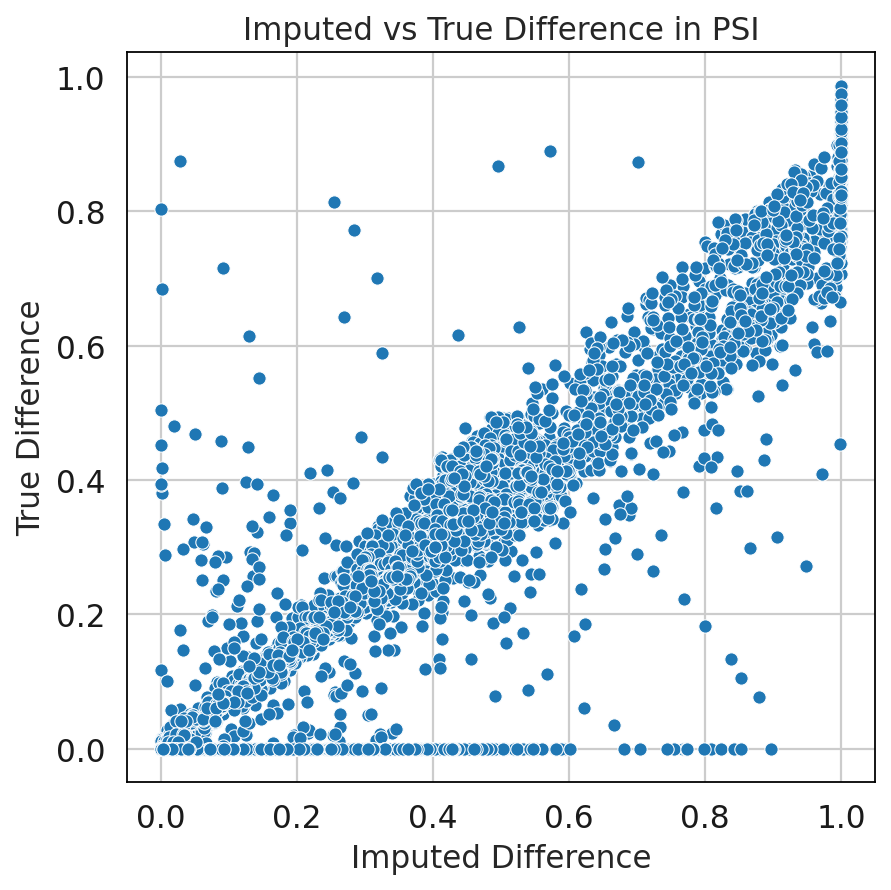

Spearman correlation between imputed and true difference: 0.8987927187052985


In [27]:
# Let's extract sampled PSI means to calculate imputed difference between groups
# convert leaflet_model.psi_samples to a dataframe rename columns to factor_
factor_psi_df = pd.DataFrame(leaflet_model.psi_learned.T)
factor_psi_df.columns = [f"factor_imputed_psi_{col}" for col in factor_psi_df.columns]

if K == 2:
    factor_psi_df["imputed_diff"] = np.abs(factor_psi_df["factor_imputed_psi_0"] - factor_psi_df["factor_imputed_psi_1"])
if K > 2:
    # Calculate variance across all factors
    factor_psi_df["imputed_diff"] = factor_psi_df.var(axis=1)

# Add factor_psi_df to adata_input.var 
adata_input.var = pd.concat([adata_input.var, factor_psi_df], axis=1)

# Plot scatterplot correlation between imputed difference and true difference 
plt.figure(figsize=(6, 6))
sns.scatterplot(x="imputed_diff", y="difference", data=adata_input.var)
plt.xlabel("Imputed Difference")
plt.ylabel("True Difference")
plt.title("Imputed vs True Difference in PSI")
plt.show()

# Calculate pearson and spearman correlation
pearson_corr = stats.pearsonr(adata_input.var["imputed_diff"], adata_input.var["difference"])[0]
spearman_corr = stats.spearmanr(adata_input.var["imputed_diff"], adata_input.var["difference"])[0]
print(f"Spearman correlation between imputed and true difference: {spearman_corr}")

In [28]:
importlib.reload(ds)

<module 'BetaDirichletFactor.differential_splicing' from '/gpfs/commons/home/kisaev/Leaflet-private/src/BetaDirichletFactor/differential_splicing.py'>

In [29]:
# Define your parameter grid
effect_sizes_to_test = [0.001, 0.01, 0.05, 0.1, 0.25]
fdr_thresholds_to_test = [0.25, 0.1, 0.05, 0.01, 0.001]

# Store results
results_summary = []

# Load junction IDs and psi_samples
top_junctions = adata_input.var["junction_id_index"].values
true_labels = adata_input.var["true_label"].values
psi_samples = leaflet_model.psi_samples

for effect_size in effect_sizes_to_test:
    for fdr_threshold in fdr_thresholds_to_test:
        print(f"Running effect_size={effect_size}, fdr_threshold={fdr_threshold}")
        
        # Step 1: Compute effect sizes
        top_fact_juncs = []
        for j in tqdm(top_junctions, desc="Computing effect sizes"):
            results_dict = ds.compute_psi_effect_size(
                psi_samples, factor_idx=0, junction_idx=j, min_effect_size=effect_size
            )
            top_fact_juncs.append(results_dict)
        top_fact_juncs_df = pd.DataFrame(top_fact_juncs)
        
        # Step 2: Compute significance
        top_fact_juncs_df_SIG = ds.compute_junctions_significance_psi(
            top_fact_juncs_df, 
            fdr_threshold=fdr_threshold, 
            min_effect_size=effect_size
        )
        top_fact_juncs_df_SIG["true_labels"] = true_labels

        # Step 3: Confusion matrix
        confusion = pd.crosstab(
            top_fact_juncs_df_SIG["true_labels"],
            top_fact_juncs_df_SIG["significant"],
            rownames=["True"],
            colnames=["Predicted"],
            dropna=False
        )

        # Fill missing entries to avoid KeyErrors
        confusion = confusion.reindex(index=["positive", "negative"], columns=[True, False], fill_value=0)

        # Step 4: Extract metrics
        tp = confusion.loc["positive", True]
        fn = confusion.loc["positive", False]
        fp = confusion.loc["negative", True]
        tn = confusion.loc["negative", False]

        total_positives = tp + fn
        total_discoveries = tp + fp

        observed_fdr = fp / total_discoveries if total_discoveries > 0 else np.nan
        power = tp / total_positives if total_positives > 0 else np.nan
        precision = tp / total_discoveries if total_discoveries > 0 else np.nan
        f1_score = 2 * precision * power / (precision + power) if (precision + power) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        results_summary.append({
            "effect_size": effect_size,
            "fdr_threshold": fdr_threshold,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "FDR": observed_fdr,
            "Power": power,
            "Precision": precision,
            "F1_score": f1_score,
            "Specificity": specificity
        })

# Convert to DataFrame for display
summary_df = pd.DataFrame(results_summary)
print(summary_df)

Running effect_size=0.001, fdr_threshold=0.25


Computing effect sizes: 100%|██████████| 9801/9801 [00:00<00:00, 15423.80it/s]


Found 9140 significant junctions with effect size > 0.001 at FDR < 0.25
Running effect_size=0.001, fdr_threshold=0.1


Computing effect sizes: 100%|██████████| 9801/9801 [00:00<00:00, 15674.28it/s]


Found 9140 significant junctions with effect size > 0.001 at FDR < 0.1
Running effect_size=0.001, fdr_threshold=0.05


...

Found 3793 significant junctions with effect size > 0.25 at FDR < 0.05
Running effect_size=0.25, fdr_threshold=0.01


Computing effect sizes: 100%|██████████| 9801/9801 [00:00<00:00, 15801.62it/s]


Found 3693 significant junctions with effect size > 0.25 at FDR < 0.01
Running effect_size=0.25, fdr_threshold=0.001


Computing effect sizes: 100%|██████████| 9801/9801 [00:00<00:00, 15557.13it/s]

Found 3513 significant junctions with effect size > 0.25 at FDR < 0.001
    effect_size  fdr_threshold    TP    FP   FN    TN       FDR     Power  \
0         0.001          0.250  4371  4769    5   656  0.521772  0.998857   
1         0.001          0.100  4371  4769    5   656  0.521772  0.998857   
2         0.001          0.050  4324  4126   52  1299  0.488284  0.988117   
3         0.001          0.010  4267  2469  109  2956  0.366538  0.975091   
4         0.001          0.001  4131  1442  245  3983  0.258748  0.944013   
5         0.010          0.250  4364  2370   12  3055  0.351945  0.997258   
6         0.010          0.100  4364  2370   12  3055  0.351945  0.997258   
7         0.010          0.050  4320  2333   56  3092  0.350669  0.987203   
8         0.010          0.010  4267  1820  109  3605  0.298998  0.975091   
9         0.010          0.001  4131  1192  245  4233  0.223934  0.944013   
10        0.050          0.250  4357   671   19  4754  0.133453  0.995658   
11  

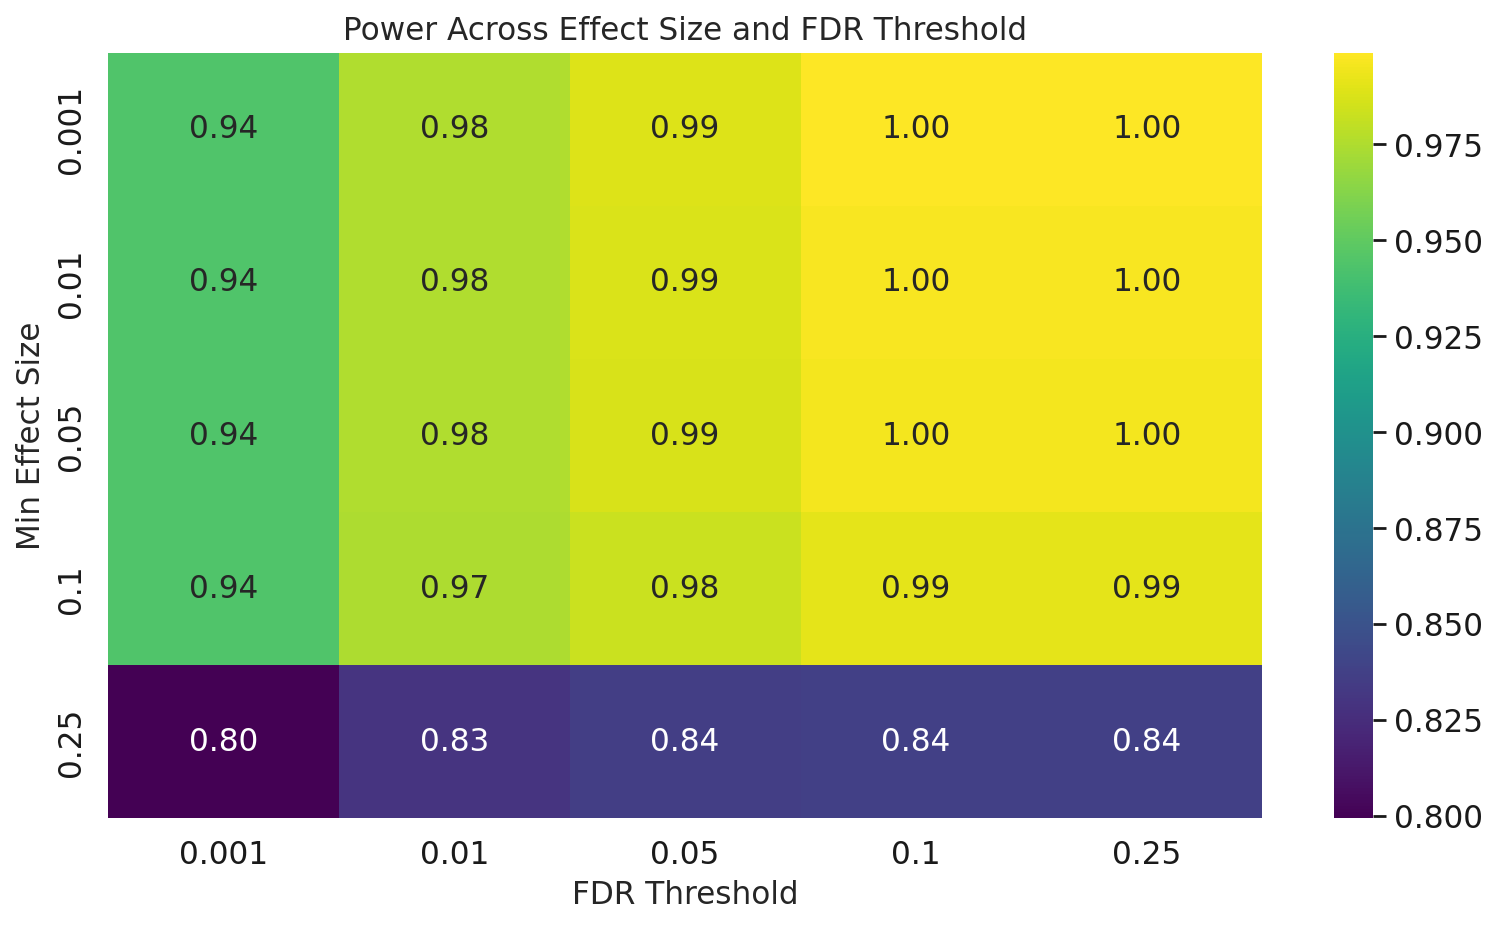

In [30]:
# Pivot the DataFrame for heatmap input
heatmap_data = summary_df.pivot(index="effect_size", columns="fdr_threshold", values="Power")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.title("Power Across Effect Size and FDR Threshold")
plt.xlabel("FDR Threshold")
plt.ylabel("Min Effect Size")
plt.tight_layout()
plt.show()


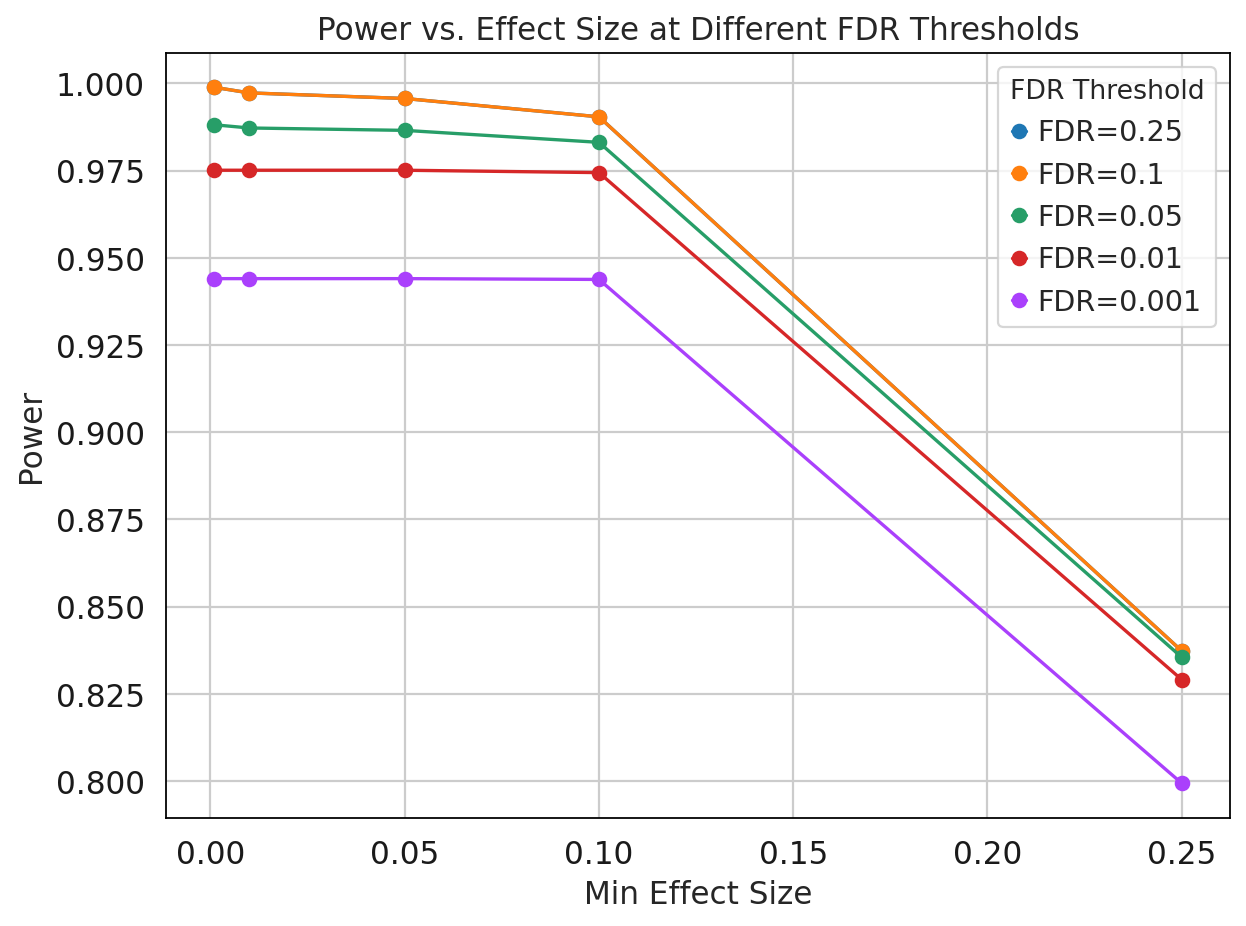

In [31]:
plt.figure(figsize=(8, 6))
for fdr in sorted(summary_df["fdr_threshold"].unique(), reverse=True):
    subset = summary_df[summary_df["fdr_threshold"] == fdr]
    plt.plot(subset["effect_size"], subset["Power"], marker="o", label=f"FDR={fdr}")

plt.xlabel("Min Effect Size")
plt.ylabel("Power")
plt.title("Power vs. Effect Size at Different FDR Thresholds")
plt.legend(title="FDR Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


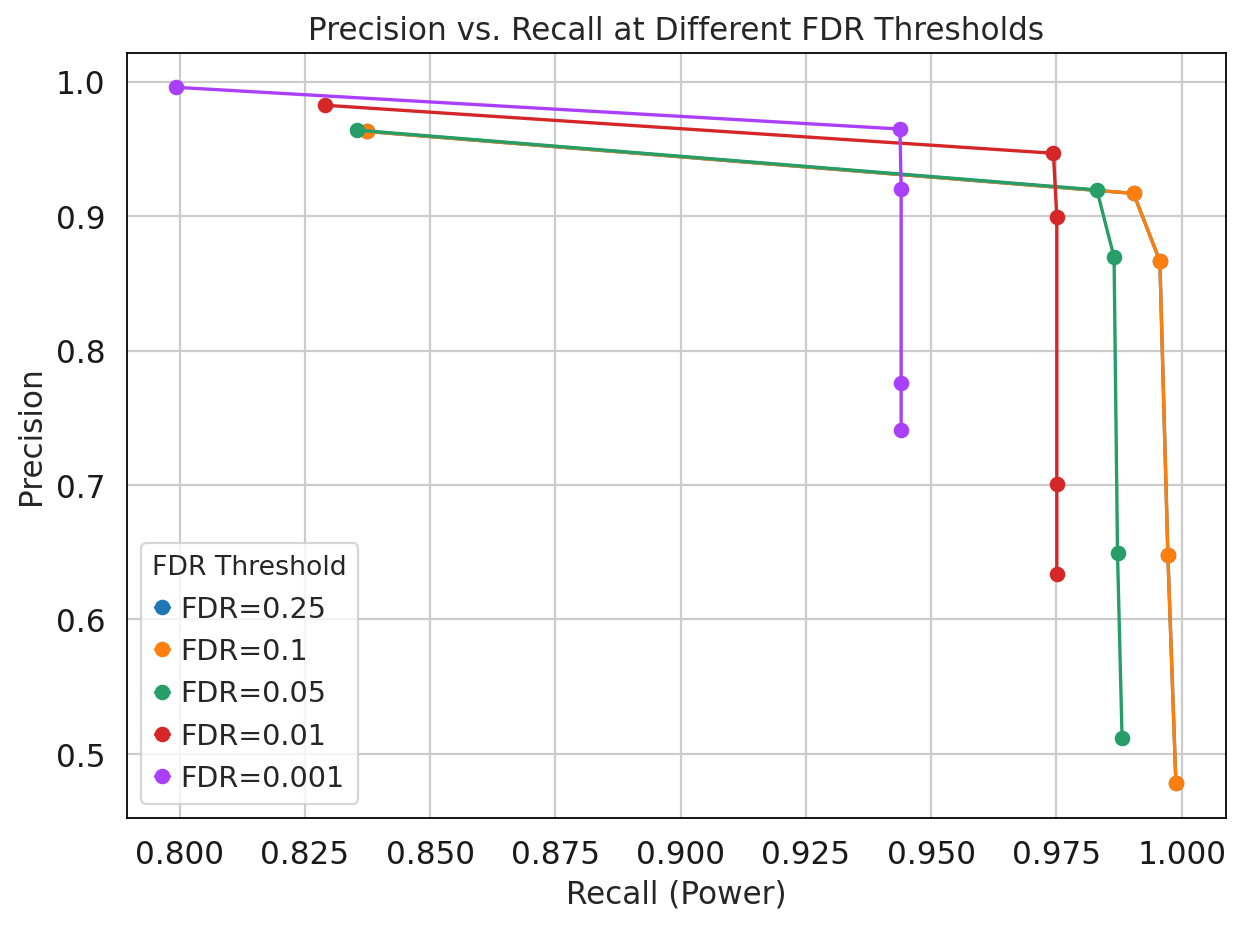

In [32]:
plt.figure(figsize=(8, 6))
for fdr in sorted(summary_df["fdr_threshold"].unique(), reverse=True):
    subset = summary_df[summary_df["fdr_threshold"] == fdr]
    plt.plot(subset["Power"], subset["Precision"], marker="o", label=f"FDR={fdr}")

plt.xlabel("Recall (Power)")
plt.ylabel("Precision")
plt.title("Precision vs. Recall at Different FDR Thresholds")
plt.legend(title="FDR Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


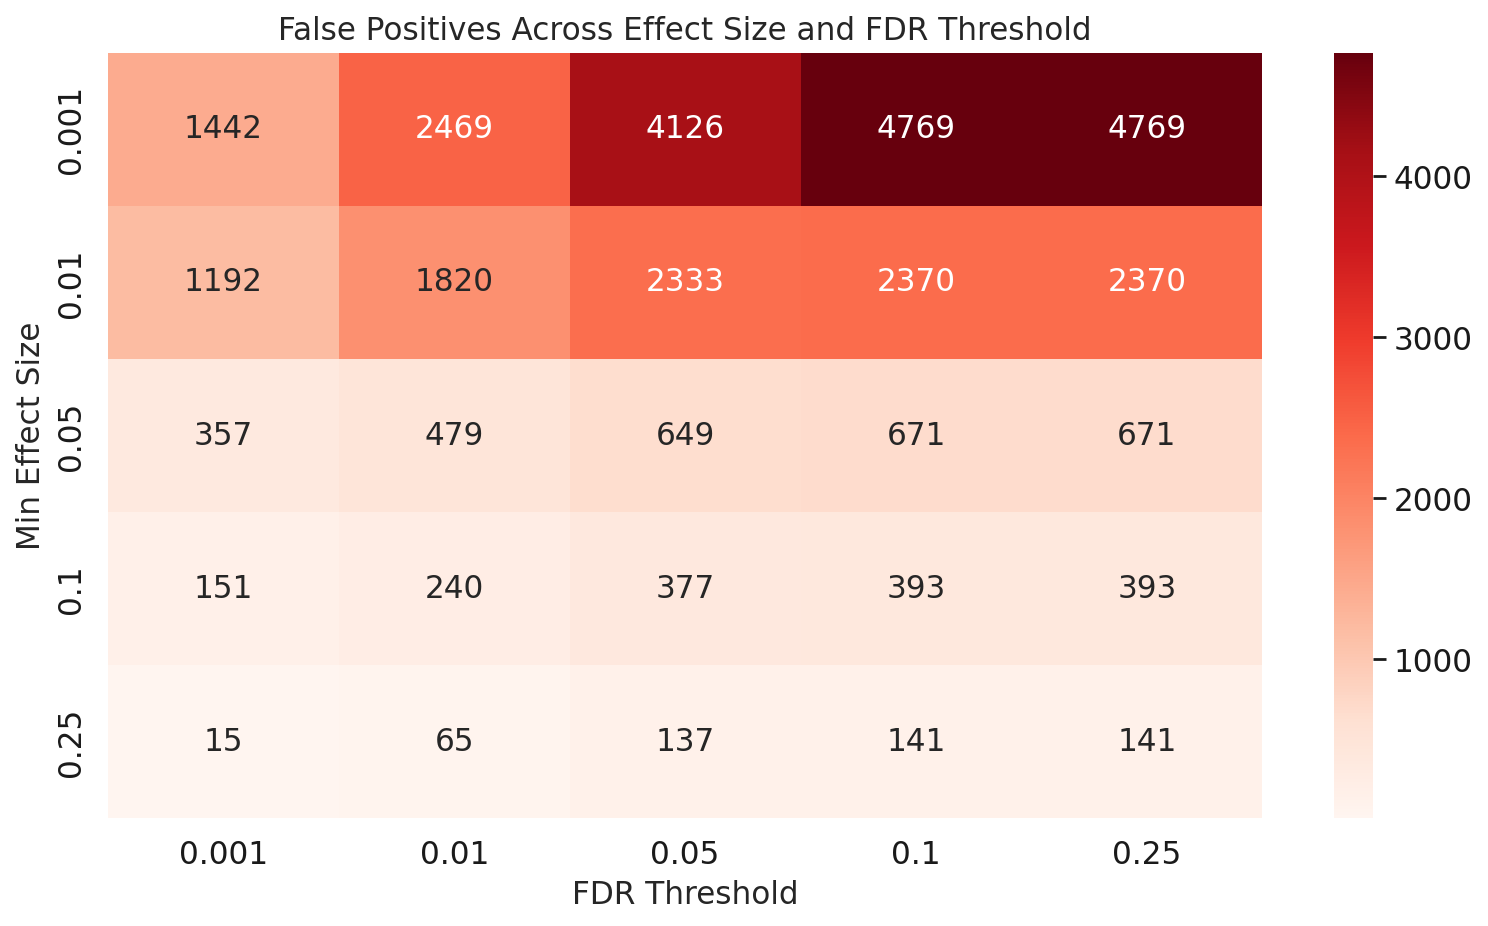

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table to visualize FP counts
fp_pivot = summary_df.pivot(index="effect_size", columns="fdr_threshold", values="FP")

plt.figure(figsize=(10, 6))
sns.heatmap(fp_pivot, annot=True, fmt="d", cmap="Reds")
plt.title("False Positives Across Effect Size and FDR Threshold")
plt.xlabel("FDR Threshold")
plt.ylabel("Min Effect Size")
plt.tight_layout()
plt.show()


In [ ]:
y = leaflet_model.y
T = leaflet_model.total_counts
alpha = torch.tensor(leaflet_model.bb_conc)
psi_samples = leaflet_model.psi_samples  
S, K, J = psi_samples.shape
print(S, K, J)

C = y.shape[0]
y_sparse = y.coalesce()
T_sparse = T.coalesce()
y_indices = y_sparse.indices()  # [2, nnz]
y_vals = y_sparse.values()
T_vals = T_sparse.values()
c_idx = y_indices[0]
j_idx = y_indices[1]
adjusted_psi = torch.zeros_like(psi_samples)


500 2 9801


In [62]:
for s in tqdm(range(S)):
    for k in range(K):
        psi_kj = psi_samples[s, k]  # [J]
        adj_kj = torch.zeros(J, device=psi_kj.device)
        for j in range(J):
            # Get all (c, j) pairs for this junction j
            mask = (j_idx == j)
            if mask.sum() == 0:
                adj_kj[j] = psi_kj[j]  # No data → fallback to prior
                continue
            y_vals_j = y_vals[mask]
            T_vals_j = T_vals[mask]
            psi_prior = psi_kj[j]
            a_post = y_vals_j + alpha * psi_prior
            b_post = T_vals_j - y_vals_j + alpha * (1 - psi_prior)
            # Sample from Beta posterior for all cells with this junction
            beta_dist = torch.distributions.Beta(a_post, b_post)
            rho_post_samples = beta_dist.sample()  # [#cells for this j]
            # Aggregate: mean posterior PSI across all cells for this j
            adj_kj[j] = rho_post_samples.mean()
        adjusted_psi[s, k] = adj_kj

  1%|          | 3/500 [00:53<2:27:53, 17.85s/it]


KeyboardInterrupt: 